In [3]:
import yfinance as yf
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

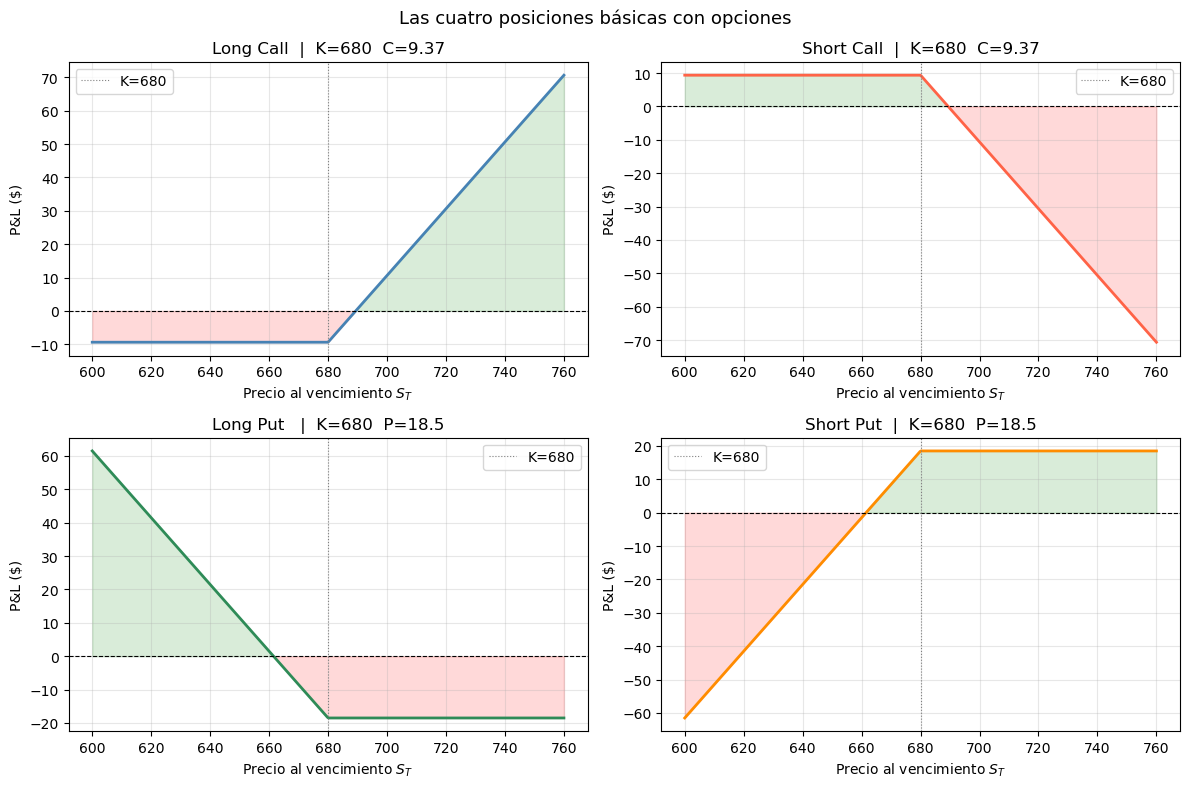

In [5]:
import numpy as np
import matplotlib.pyplot as plt

S_range = np.linspace(600, 760, 500)   # rango de precios al vencimiento
K = 680
C = 9.37    # prima del call
P = 18.50   # prima del put

# --- Payoffs brutos ---
call_long_bruto  =  np.maximum(S_range - K, 0)
call_short_bruto = -np.maximum(S_range - K, 0)
put_long_bruto   =  np.maximum(K - S_range, 0)
put_short_bruto  = -np.maximum(K - S_range, 0)

# --- P&L neto ---
pnl_call_long  = call_long_bruto  - C
pnl_call_short = call_short_bruto + C
pnl_put_long   = put_long_bruto   - P
pnl_put_short  = put_short_bruto  + P

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

configs = [
    (axes[0,0], pnl_call_long,  f'Long Call  |  K={K}  C={C}',  'steelblue'),
    (axes[0,1], pnl_call_short, f'Short Call  |  K={K}  C={C}', 'tomato'),
    (axes[1,0], pnl_put_long,   f'Long Put   |  K={K}  P={P}',  'seagreen'),
    (axes[1,1], pnl_put_short,  f'Short Put  |  K={K}  P={P}',  'darkorange'),
]

for ax, pnl, title, color in configs:
    ax.plot(S_range, pnl, color=color, linewidth=2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(K, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K}')
    ax.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green')
    ax.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red')
    ax.set_title(title)
    ax.set_xlabel('Precio al vencimiento $S_T$')
    ax.set_ylabel('P&L ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Las cuatro posiciones básicas con opciones', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
def payoff_estrategia(S_range, legs):
    """
    Calcula el P&L neto de una estrategia con cualquier número de legs.

    Parámetros:
    -----------
    S_range : array de precios al vencimiento
    legs    : lista de dicts, cada uno con:
        tipo     : 'call' o 'put'
        K        : strike
        prima    : prima pagada (+) o cobrada (-)
        posicion : +1 (long) o -1 (short)

    Retorna:
    --------
    Array de P&L neto para cada precio en S_range
    """
    total = np.zeros(len(S_range))

    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)

        pnl    = leg['posicion'] * (payoff - leg['prima'])
        total += pnl

    return total


def graficar_estrategia(S_range, pnl, titulo, K_lines=None):
    """Grafica el P&L de una estrategia con formato estándar."""
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8,
                        linestyle=':', label=label)
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0),
                     alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0),
                     alpha=0.15, color='red',   label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

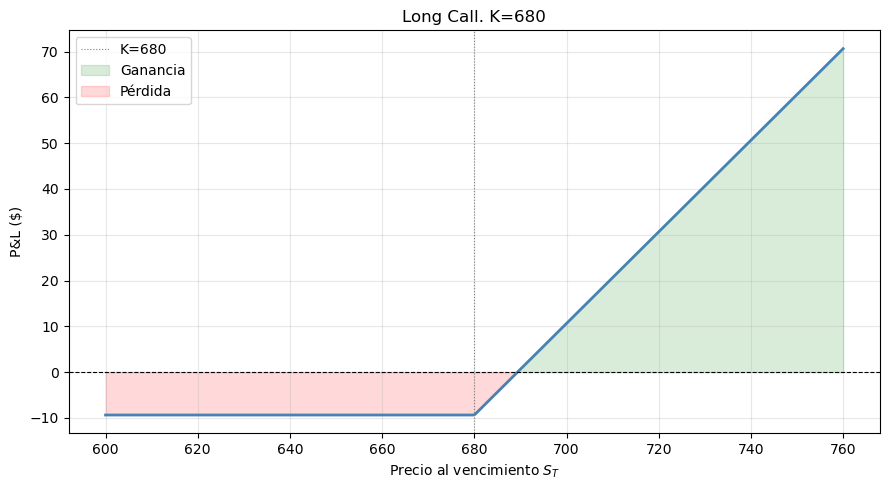

In [7]:
legs_call = [
    {'tipo': 'call', 'K': 680, 'prima': 9.37, 'posicion': +1}
]

pnl = payoff_estrategia(S_range, legs_call)
graficar_estrategia(S_range, pnl, 'Long Call. K=680',
                    K_lines=[(680, 'K=680')])

In [9]:
tk  = yf.Ticker('SPY')
S0  = tk.fast_info['last_price']
exp = '2026-04-17'
K   = 680

calls = tk.option_chain(exp).calls
puts  = tk.option_chain(exp).puts

row_call = calls[calls['strike'] == K].iloc[0]
row_put  = puts[puts['strike'] == K].iloc[0]

C = (row_call['bid'] + row_call['ask']) / 2
P = (row_put['bid']  + row_put['ask'])  / 2

print(f"S0={S0:.2f}  K={K}  C={C:.4f}  P={P:.4f}")

S0=634.09  K=680  C=0.9950  P=46.6250


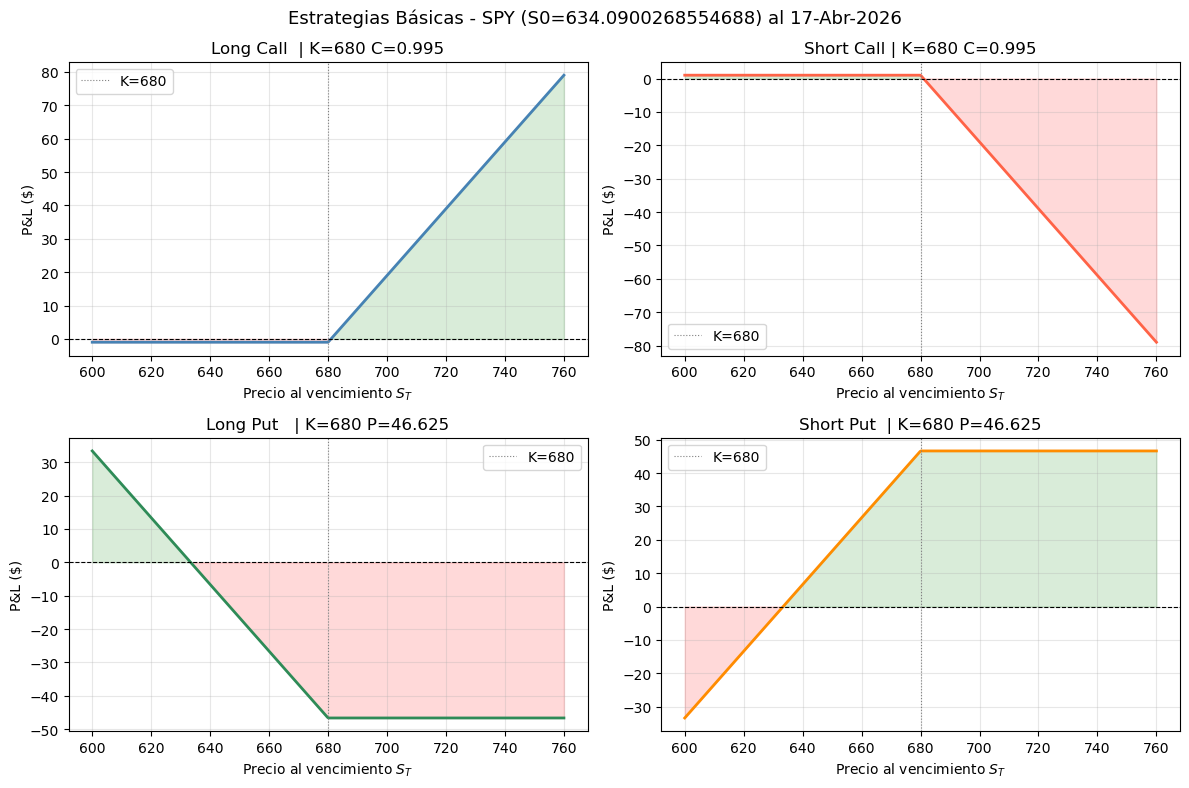

In [ ]:
pnl_call_long  = np.maximum(S_range - K, 0) - C
pnl_call_short = -np.maximum(S_range - K, 0) + C
pnl_put_long   = np.maximum(K - S_range, 0) - P
pnl_put_short  = -np.maximum(K - S_range, 0) + P

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
configs = [
    (axes[0,0], pnl_call_long,  f'Long Call  | K={K} C={C}',  'steelblue'),
    (axes[0,1], pnl_call_short, f'Short Call | K={K} C={C}', 'tomato'),
    (axes[1,0], pnl_put_long,   f'Long Put   | K={K} P={P}',  'seagreen'),
    (axes[1,1], pnl_put_short,  f'Short Put  | K={K} P={P}',  'darkorange'),
]

for ax, pnl, title, color in configs:
    ax.plot(S_range, pnl, color=color, linewidth=2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(K, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K}')
    ax.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green')
    ax.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red')
    ax.set_title(title)
    ax.set_xlabel('Precio al vencimiento $S_T$')
    ax.set_ylabel('P&L ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Estrategias Básicas - SPY (S0={S0}) al 17-Abr-2026', fontsize=13)
plt.tight_layout()
plt.show()

#### Preguntas 

Con el S0 actual, ¿cuál de las cuatro posiciones básicas tiene el break-even más cercano al precio actual? ¿Qué implica eso?

    Las posiciones Put tienen el precio mas corto por que al precio strike de 680 en el call tienes que sumarle el precio de la prima, este caso es 680+0.995 y en el caso de los puts se ve en la grafica pero es restarle a 680 la prima que es 46.625 y da 633.75, muy cercano al precio actual. esto implica que la probabilidad del put es muy alta, si baja una cosa de nada ya estas ganando, en el otro caso tiene que subir 45 dolares o un 7% 

Si SPY termina exactamente en K al vencimiento, ¿cuánto gana o pierde cada posición? ¿Por qué?

    Long call: -0.995, aca pierdes solo 0.995 por que no ganas nada al activar la opcion del activo a 680

    Short call:0.995 como das la opcion de vender, no tiene sentido que active la opcion por que en el mercado esta al mismo precio que el strike

    Long put:-46.625: en este caso pierdes 46 por que pagaste la prima y esperabas que bajara el precio y no fue el caso

    Short put:46.625: Aca ganas 46 por que se quedo en el precio strike por lo que la otra parte de la moneda no gana nada por estar comprando un activo al mismo precio que esta al mercado

Compara la pérdida máxima de una long call vs. una short put. ¿Cuál tiene más riesgo? ¿Por qué?

    Claramente el riesgo mas grande lo tiene el short put por que puedes perder todo si el S&P baja a 0 que es imposible claramente pero en ese que es de 46 dolares, en el otro caso tu solo pierdes 0.995

¿En qué escenario de mercado elegirías una long put sobre una short call, si ambas expresan una visión bajista? 

    es distinto por que el long put crees que va a tener una bajada inmensa y en un short call apuestas a que este muy estable el mercado, que no tenga subidas extremas por lo que una volatilidad en el mercado mas baja.